In [24]:
from sklearn.metrics import accuracy_score
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [25]:
data  = make_classification(n_samples=100, n_features=2, n_informative=2, n_redundant=0, n_classes=2, random_state=42)

In [26]:
X = data[0]
y = data[1]
# print(f"y is {[y==0]}")

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [28]:
model = LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print(f"coefficients: {model.coef_}, intercept: {model.intercept_}")

Accuracy: 0.95
coefficients: [[ 3.06127461 -0.68478105]], intercept: [0.23246397]


Perceptron Trick


In [29]:
import numpy as np

class perceptron:
    def __init__(self, learning_rate=0.01, n_iter=1000):
        self.learning_rate = learning_rate
        self.n_iter = n_iter
        self.weights = None
        self.intercept = None

    def fit(self, X_train, y_train):
        self.weights = np.zeros(X_train.shape[1])
        self.intercept = 0
        
        for i in range(self.n_iter):
            idx = i % X_train.shape[0]   # to stay within training data range
            
            data_point = X_train[idx]
            y_actual = y_train[idx]

            y_predicted = np.dot(data_point, self.weights) + self.intercept

            if y_predicted >= 0:
                y_predicted = 1
            else:
                y_predicted = 0

            error = y_actual - y_predicted

            if error != 0:
                self.weights += self.learning_rate * error * data_point
                self.intercept += self.learning_rate * error

    def predict(self, X_test):
        y_predicted = np.dot(X_test, self.weights) + self.intercept
        y_predicted[y_predicted >= 0] = 1
        y_predicted[y_predicted < 0] = 0
        return y_predicted

In [30]:
new_model = perceptron(learning_rate=0.01, n_iter=1000)
new_model.fit(X_train, y_train)
y_pred_new = new_model.predict(X_test)
accuracy_new = accuracy_score(y_test, y_pred_new)
print("Accuracy of custom perceptron model:", accuracy_new*100)

Accuracy of custom perceptron model: 100.0


In [31]:
print(f"coefficients: {new_model.weights}, intercept: {new_model.intercept}")

coefficients: [ 0.05247561 -0.01670351], intercept: 0.0


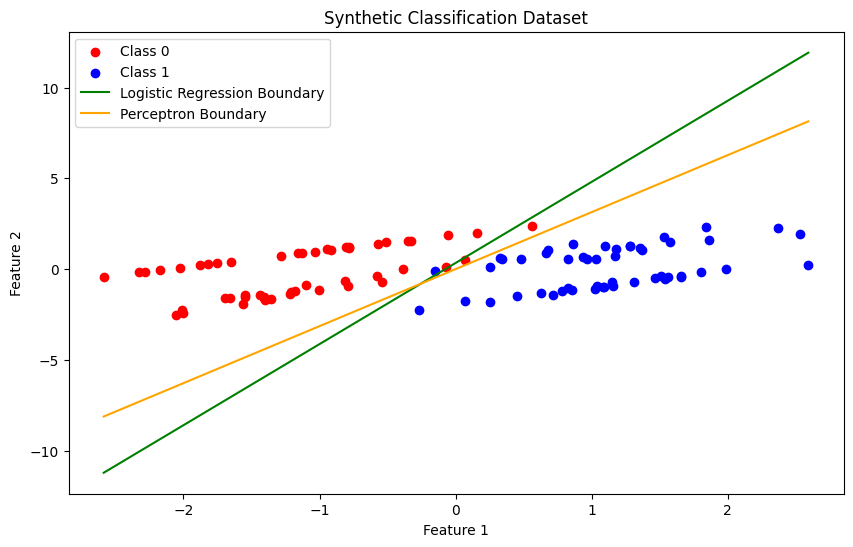

In [32]:
plt.figure(figsize=(10, 6))

# scatter points
plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], color='red', label='Class 0')
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color='blue', label='Class 1')

# logistic regression decision boundary
x1 = np.linspace(X[:, 0].min(), X[:, 0].max(), 100)
x2 = -(model.coef_[0][0] * x1 + model.intercept_[0]) / model.coef_[0][1]
plt.plot(x1, x2, color='green', label='Logistic Regression Boundary')

# perceptron decision boundary
x2_perceptron = -(new_model.weights[0] * x1 + new_model.intercept) / new_model.weights[1]
plt.plot(x1, x2_perceptron, color='orange', label='Perceptron Boundary')

plt.title('Synthetic Classification Dataset')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()

Sigmoid Function


In [33]:
import numpy as np

class perceptron_with_sigmoid:
    def __init__(self, learning_rate=0.01, n_iter=1000):
        self.learning_rate = learning_rate
        self.n_iter = n_iter
        self.weights = None
        self.intercept = None

    def fit(self, X_train, y_train):
        self.weights = np.zeros(X_train.shape[1])
        self.intercept = 0
        
        for i in range(self.n_iter):
            idx = i % X_train.shape[0]   
            
            data_point = X_train[idx]
            y_actual = y_train[idx]

            z = np.dot(data_point, self.weights) + self.intercept
            y_predicted = 1 / (1 + np.exp(-z))

            error = y_actual - y_predicted

            self.weights += self.learning_rate * error * data_point
            self.intercept += self.learning_rate * error

    def predict(self, X_test):
        z = np.dot(X_test, self.weights) + self.intercept
        y_predicted = 1 / (1 + np.exp(-z))
        return np.where(y_predicted >= 0.5, 1, 0)

In [34]:
perceptron_with_sigmoid_model = perceptron_with_sigmoid(learning_rate=0.01, n_iter=1000)
perceptron_with_sigmoid_model.fit(X_train, y_train)
y_pred_perceptron_with_sigmoid = perceptron_with_sigmoid_model.predict(X_test)
accuracy_perceptron_with_sigmoid = accuracy_score(y_test, y_pred_perceptron_with_sigmoid)
print(f"Coefficients: {perceptron_with_sigmoid_model.weights}, Intercept: {perceptron_with_sigmoid_model.intercept}")
print("Accuracy of perceptron with sigmoid model:", accuracy_perceptron_with_sigmoid*100)

Coefficients: [ 1.97153025 -0.30733194], Intercept: 0.11424066540524264
Accuracy of perceptron with sigmoid model: 95.0


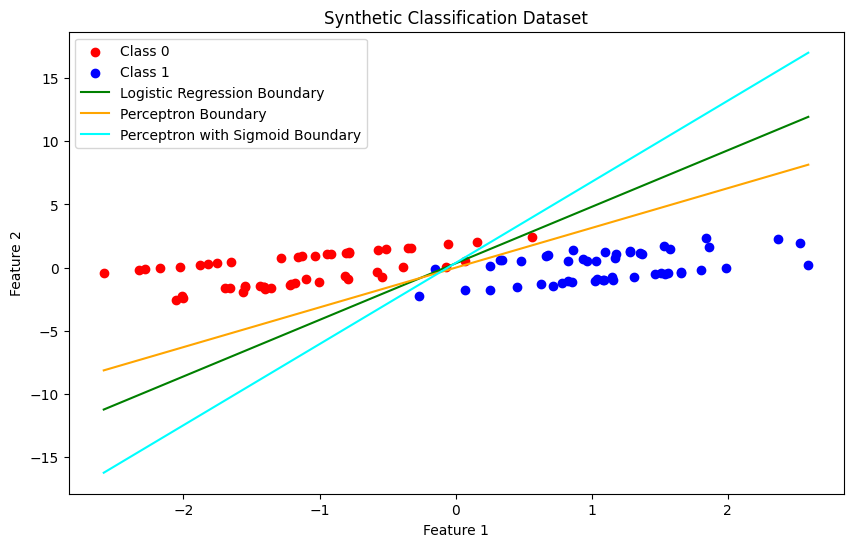

In [35]:
plt.figure(figsize=(10, 6))

# scatter points
plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], color='red', label='Class 0')
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color='blue', label='Class 1')

# logistic regression decision boundary
x1 = np.linspace(X[:, 0].min(), X[:, 0].max(), 100)
x2 = -(model.coef_[0][0] * x1 + model.intercept_[0]) / model.coef_[0][1]
plt.plot(x1, x2, color='green', label='Logistic Regression Boundary')

# perceptron decision boundary
x2_perceptron = -(new_model.weights[0] * x1 + new_model.intercept) / new_model.weights[1]
plt.plot(x1, x2_perceptron, color='orange', label='Perceptron Boundary')

# perceptron with sigmoid decision boundary
x2_perceptron_sigmoid = -(perceptron_with_sigmoid_model.weights[0] * x1 + perceptron_with_sigmoid_model.intercept) / perceptron_with_sigmoid_model.weights[1]
plt.plot(x1, x2_perceptron_sigmoid, color='cyan', label='Perceptron with Sigmoid Boundary')

plt.title('Synthetic Classification Dataset')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()

Gradient Descent with sigmoid Function

In [36]:
import numpy as np

class sigmoid_gradient_descent:
    def __init__(self, learning_rate=0.01, n_iter=1000):
        self.learning_rate = learning_rate
        self.n_iter = n_iter
        self.weights = None
        self.intercept = None

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def fit(self, X_train, y_train):
        X_train = np.insert(X_train, 0, 1, axis=1)
        self.weights = np.zeros(X_train.shape[1])

        for i in range(self.n_iter):
            y_hat = self.sigmoid(np.dot(X_train, self.weights))
            error = y_train - y_hat
            gradient = -np.dot(X_train.T, error) / X_train.shape[0]
            self.weights = self.weights - self.learning_rate * gradient

        self.intercept = self.weights[0]
        self.weights = self.weights[1:]

    def predict(self, X_test):
        y_hat = self.sigmoid(np.dot(X_test, self.weights) + self.intercept)
        return np.where(y_hat >= 0.5, 1, 0)

In [37]:
sigmoid_gradient_descent_model = sigmoid_gradient_descent(learning_rate=0.01, n_iter=5000)
sigmoid_gradient_descent_model.fit(X_train, y_train)
y_pred_sigmoid_gradient_descent = sigmoid_gradient_descent_model.predict(X_test)
accuracy_sigmoid_gradient_descent = accuracy_score(y_test, y_pred_sigmoid_gradient_descent)
print(f"Coefficients: {sigmoid_gradient_descent_model.weights}, Intercept: {sigmoid_gradient_descent_model.intercept}")
print("Accuracy of sigmoid gradient descent model:", accuracy_sigmoid_gradient_descent*100)

Coefficients: [ 3.67018308 -0.83857026], Intercept: 0.23230188399446514
Accuracy of sigmoid gradient descent model: 95.0


In [38]:
# Accuracy: 0.95
# coefficients: [[ 3.06127461 -0.68478105]], intercept: [0.23246397]


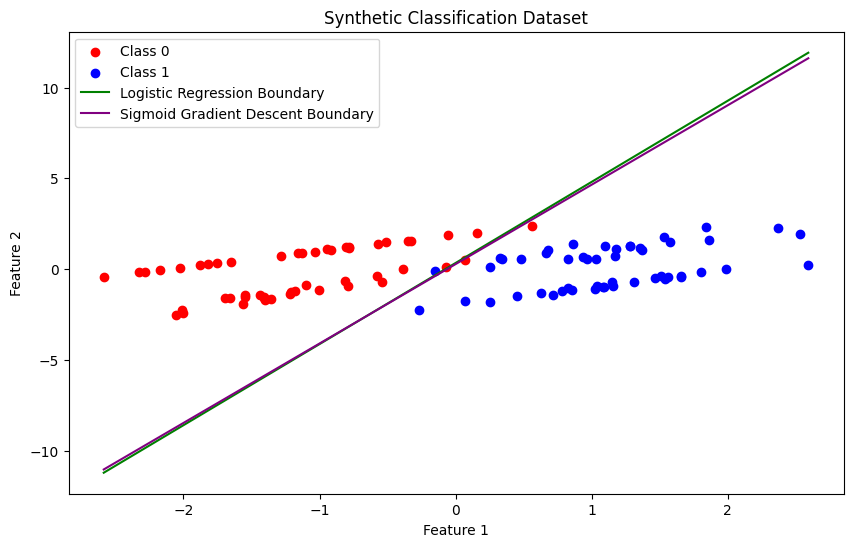

In [39]:
plt.figure(figsize=(10, 6))

# scatter points
plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], color='red', label='Class 0')
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color='blue', label='Class 1')

# logistic regression decision boundary
x1 = np.linspace(X[:, 0].min(), X[:, 0].max(), 100)
x2 = -(model.coef_[0][0] * x1 + model.intercept_[0]) / model.coef_[0][1]
plt.plot(x1, x2, color='green', label='Logistic Regression Boundary')

# perceptron decision boundary
# x2_perceptron = -(new_model.weights[0] * x1 + new_model.intercept) / new_model.weights[1]
# plt.plot(x1, x2_perceptron, color='orange', label='Perceptron Boundary')

# perceptron with sigmoid decision boundary
# x2_perceptron_sigmoid = -(perceptron_with_sigmoid_model.weights[0] * x1 + perceptron_with_sigmoid_model.intercept) / perceptron_with_sigmoid_model.weights[1]
# plt.plot(x1, x2_perceptron_sigmoid, color='cyan', label='Perceptron with Sigmoid Boundary')

# sigmoid gradient descent decision boundary
x2_sigmoid_gradient_descent = -(sigmoid_gradient_descent_model.weights[0] * x1 + sigmoid_gradient_descent_model.intercept) / sigmoid_gradient_descent_model.weights[1]
plt.plot(x1, x2_sigmoid_gradient_descent, color='purple', label='Sigmoid Gradient Descent Boundary')

plt.title('Synthetic Classification Dataset')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()